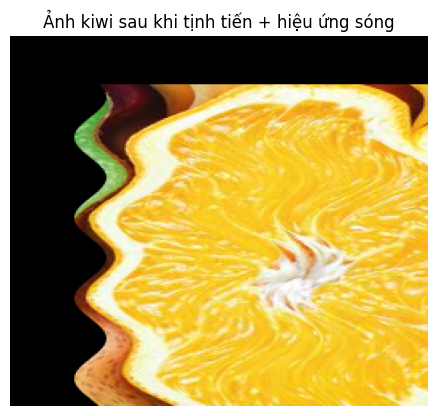

In [3]:
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt
from scipy import ndimage as nd

# 1. Đọc ảnh gốc (ví dụ: ảnh chứa quả kiwi)
data = iio.imread('exercise/colorful-ripe-tropical-fruits.jpg')

# 2. Cắt vùng chứa quả kiwi (thay toạ độ phù hợp với ảnh thật của bạn)
kiwi = data[150:380, 270:530].copy()  # (200x200 ảnh kiwi)

# 3. Tịnh tiến kiwi xuống 30px, sang phải 50px
shifted_kiwi = nd.shift(kiwi, shift=(30, 50, 0))  # (row, col, channel)

# 4. Tạo hiệu ứng sóng bằng sin (wave effect)
H, W, _ = shifted_kiwi.shape
Y, X = np.indices((H, W))

# Hiệu ứng sóng theo trục x
offset = 10 * np.sin(2 * np.pi * Y / 50.0)  # biên độ 10, bước sóng 50px
map_x = X + offset
map_y = Y

# Kết hợp thành map toạ độ
coords = np.array([map_y, map_x])

# Áp dụng map_coordinates trên từng kênh màu
wave_kiwi = np.zeros_like(shifted_kiwi)
for i in range(3):  # RGB
    wave_kiwi[:, :, i] = nd.map_coordinates(shifted_kiwi[:, :, i], coords, order=1, mode='reflect')

# 5. Lưu kết quả ra file
iio.imwrite('kiwi_wave.jpg', wave_kiwi)

# 6. Hiển thị ảnh kết quả
plt.imshow(wave_kiwi)
plt.title("Ảnh kiwi sau khi tịnh tiến + hiệu ứng sóng")
plt.axis('off')
plt.show()


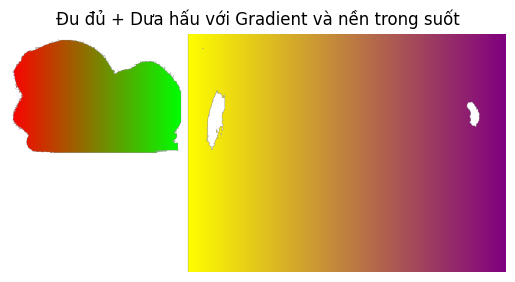

In [14]:
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt

# ------------------------
# Hàm: chuyển RGB thành RGBA với nền trong suốt
def rgb_to_rgba(image):
    gray = np.mean(image, axis=2)
    alpha = (gray < 250).astype(np.uint8) * 255  # mask nền trắng
    rgba = np.dstack([image, alpha])
    return rgba

# ------------------------
# Hàm: áp dụng gradient màu lên ảnh theo chiều ngang
def apply_gradient(image, start_color, end_color):
    H, W, _ = image.shape
    alpha = image[:, :, 3] / 255.0  # kênh alpha

    # Tạo gradient từ trái → phải
    gradient = np.linspace(start_color, end_color, W).astype(np.uint8)
    gradient = np.tile(gradient, (H, 1, 1))  # mở rộng theo chiều dọc

    out = np.zeros_like(image)
    for c in range(3):  # áp dụng cho R, G, B
        out[:, :, c] = (gradient[:, :, c] * alpha).astype(np.uint8)
    out[:, :, 3] = image[:, :, 3]  # giữ nguyên alpha
    return out

# ------------------------
# Đọc ảnh (phải là ảnh JPG với nền trắng)
du_du = iio.imread('exercise/du-du.jpg')
dua_hau = iio.imread('exercise/dua-hau.jpg')

# Chuyển sang RGBA (tạo kênh alpha)
du_du = rgb_to_rgba(du_du)
dua_hau = rgb_to_rgba(dua_hau)

# Gradient màu
red_to_green = [(255, 0, 0), (0, 255, 0)]
yellow_to_purple = [(255, 255, 0), (128, 0, 128)]

# Áp dụng gradient
papaya_colored = apply_gradient(du_du, red_to_green[0], red_to_green[1])
watermelon_colored = apply_gradient(dua_hau, yellow_to_purple[0], yellow_to_purple[1])

# ------------------------
# Tạo canvas nền trong suốt
H = max(papaya_colored.shape[0], watermelon_colored.shape[0])
W = papaya_colored.shape[1] + watermelon_colored.shape[1] + 20
canvas = np.zeros((H, W, 4), dtype=np.uint8)  # RGBA

# Dán đu đủ bên trái
canvas[0:papaya_colored.shape[0], 0:papaya_colored.shape[1], :] = papaya_colored

# Dán dưa hấu bên phải
x_offset = papaya_colored.shape[1] + 20
canvas[0:watermelon_colored.shape[0], x_offset:x_offset + watermelon_colored.shape[1], :] = watermelon_colored

# ------------------------
# Lưu ảnh PNG với nền trong suốt
iio.imwrite('combined_fruits.png', canvas)

# Hiển thị kết quả
plt.imshow(canvas)
plt.axis('off')
plt.title("Đu đủ + Dưa hấu với Gradient và nền trong suốt")
plt.show()


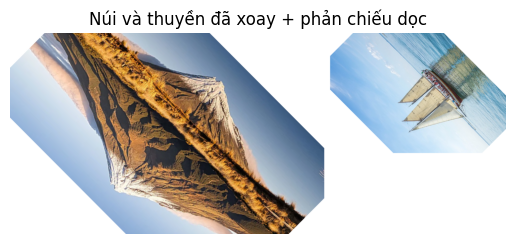

In [16]:
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt
from scipy import ndimage as nd

# ------------------------
# Hàm chuyển RGBA → RGB nếu ảnh có alpha
def rgba_to_rgb(image_rgba, background=(255, 255, 255)):
    if image_rgba.shape[2] == 3:
        return image_rgba  # đã là RGB
    rgb = image_rgba[..., :3].astype(float)
    alpha = image_rgba[..., 3:4] / 255.0
    bg = np.array(background).reshape(1, 1, 3)
    return (rgb * alpha + bg * (1 - alpha)).astype(np.uint8)

# ------------------------
# Đọc ảnh núi và thuyền
mountain = iio.imread('exercise/nui.png')
boat = iio.imread('exercise/thuyen.png')

# ------------------------
# Xoay ảnh 45 độ, giữ kích thước (reshape=False)
rotated_mountain = nd.rotate(mountain, 45, reshape=False)
rotated_boat = nd.rotate(boat, 45, reshape=False)

# ------------------------
# Phản chiếu dọc (vertical mirror)
mirror_mountain = np.flipud(rotated_mountain)
mirror_boat = np.flipud(rotated_boat)

# ------------------------
# Chuyển RGBA → RGB nếu cần
mirror_mountain = rgba_to_rgb(mirror_mountain)
mirror_boat = rgba_to_rgb(mirror_boat)

# ------------------------
# Tạo canvas nền trắng
H = max(mirror_mountain.shape[0], mirror_boat.shape[0])
W = mirror_mountain.shape[1] + mirror_boat.shape[1] + 20
canvas = np.ones((H, W, 3), dtype=np.uint8) * 255  # ảnh trắng RGB

# Ghép ảnh núi bên trái
canvas[0:mirror_mountain.shape[0], 0:mirror_mountain.shape[1], :] = mirror_mountain

# Ghép ảnh thuyền bên phải
x_offset = mirror_mountain.shape[1] + 20
canvas[0:mirror_boat.shape[0], x_offset:x_offset + mirror_boat.shape[1], :] = mirror_boat

# ------------------------
# Lưu và hiển thị kết quả
iio.imwrite('mountain_boat_mirror.jpg', canvas)

plt.imshow(canvas)
plt.axis('off')
plt.title("Núi và thuyền đã xoay + phản chiếu dọc")
plt.show()


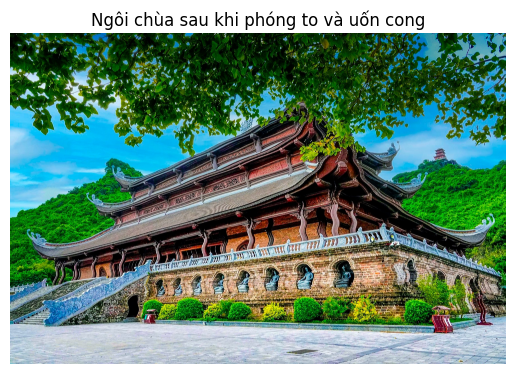

In [20]:

# ------------------------
# Đọc ảnh ngôi chùa
pagoda = iio.imread('exercise/chua.png')  # ảnh JPG hoặc PNG đều được

# ------------------------
# Phóng to ảnh lên 5 lần
zoomed_pagoda = nd.zoom(pagoda, (5, 5, 1))  

# ------------------------
# Định nghĩa hàm biến đổi hình học (uốn cong theo trục y)
def warp_curve(outcoord):
    y, x = outcoord
    shift_x = 20 * np.sin(y / 50.0)  # hiệu ứng sóng theo chiều dọc
    return y, x + shift_x  # uốn theo trục ngang

# ------------------------
# Áp dụng biến dạng
warped = np.zeros_like(zoomed_pagoda)
for c in range(3):  # từng kênh R, G, B
    warped[:, :, c] = nd.geometric_transform(
        zoomed_pagoda[:, :, c],
        warp_curve,
        order=1,
        mode='reflect'
    )
if warped.shape[2] == 4:
    warped = warped[:, :, :3]
# ------------------------
# Lưu ảnh kết quả
iio.imwrite('pagoda_warped.jpg', warped)

# Hiển thị
plt.imshow(warped)
plt.axis('off')
plt.title("Ngôi chùa sau khi phóng to và uốn cong")
plt.show()


In [ ]:
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt
from scipy import ndimage as nd

# ---------------------
# Biến đổi sóng (sin)
def wave_transform(amplitude):
    def transform(outcoord):
        y, x = outcoord
        shift_x = amplitude * np.sin(y / 30.0)
        return y, x + shift_x
    return transform

# ---------------------
# Hàm chính menu
def main():
    # Danh sách ảnh
    image_files = {
        "1": "exercise/chua.png",
        "2": "exercise/dua-hau.jpg",
        "3": "exercise/du-du.jpg"
    }

    print("=== CHỌN ẢNH ===")
    for key, val in image_files.items():
        print(f"{key}: {val}")
    img_choice = input("Nhập số ảnh bạn chọn (1-3): ").strip()
    img_path = image_files.get(img_choice)

    if not img_path:
        print("❌ Ảnh không hợp lệ.")
        return

    img = iio.imread(img_path)
    print("Ảnh đã được tải thành công.")

    print("\n=== MENU PHÉP BIẾN ĐỔI ===")
    print("1: Tịnh tiến")
    print("2: Xoay")
    print("3: Phóng to / Thu nhỏ")
    print("4: Làm mờ Gaussian")
    print("5: Biến dạng sóng")

    choice = input("Chọn phép biến đổi (1-5): ").strip()
    result = None

    if choice == "1":
        dx = int(input("Nhập số pixel tịnh tiến theo trục x: "))
        dy = int(input("Nhập số pixel tịnh tiến theo trục y: "))
        shift = (dy, dx, 0) if img.ndim == 3 else (dy, dx)
        result = nd.shift(img, shift=shift)

    elif choice == "2":
        angle = float(input("Nhập góc xoay (độ): "))
        reshape_str = input("Giữ reshape? (y/n): ").strip().lower()
        reshape = True if reshape_str == 'y' else False
        result = nd.rotate(img, angle=angle, reshape=reshape)

    elif choice == "3":
        zoom_factor = float(input("Nhập hệ số zoom (ví dụ 0.5 thu nhỏ, 2 phóng to): "))
        if img.ndim == 3:
            result = nd.zoom(img, (zoom_factor, zoom_factor, 1))
        else:
            result = nd.zoom(img, zoom_factor)

    elif choice == "4":
        sigma = float(input("Nhập giá trị sigma cho Gaussian blur: "))
        result = nd.gaussian_filter(img, sigma=sigma)

    elif choice == "5":
        amp = float(input("Nhập biên độ sóng (amplitude): "))
        result = np.zeros_like(img)
        for c in range(img.shape[2]) if img.ndim == 3 else [0]:
            channel = img[:, :, c] if img.ndim == 3 else img
            warped = nd.geometric_transform(channel, wave_transform(amp), order=1, mode='reflect')
            if img.ndim == 3:
                result[:, :, c] = warped
            else:
                result = warped

    else:
        print(" Lựa chọn không hợp lệ.")
        return

    # Hiển thị ảnh kết quả
    plt.imshow(result, cmap='gray' if result.ndim == 2 else None)
    plt.axis('off')
    plt.title("Kết quả")
    plt.show()

    # Lưu ảnh kết quả
    output_name = input("Nhập tên file để lưu (VD: output.jpg): ").strip()
    if result.ndim == 3 and result.shape[2] == 4:
        result = result[:, :, :3]  # loại bỏ alpha nếu lưu JPG
    iio.imwrite(output_name, result)
    print(f"✅ Ảnh đã lưu vào {output_name}")

# ---------------------
if __name__ == "__main__":
    main()


=== CHỌN ẢNH ===
1: exercise/chua.png
2: exercise/dua-hau.jpg
3: exercise/du-du.jpg
Ảnh đã được tải thành công.

=== MENU PHÉP BIẾN ĐỔI ===
1: Tịnh tiến
2: Xoay
3: Phóng to / Thu nhỏ
4: Làm mờ Gaussian
5: Biến dạng sóng
